# ***Projet Analyse du réseau social de Collaboration Scientifique (CA-HepTh)***
##Safa Ben Salha 1ère année de Master de Recherche en Business Computing


## **Partie 1 : Collecte et construction du réseau**
###**Identification de la source de données**
Source choisie : Le jeu de données a été extrait du portail SNAP (Stanford Network Analysis Project): https://snap.stanford.edu/data/ca-HepTh.html

###**Description:**
Le réseau ca-HepTh illustre le graphe de collaboration scientifique des auteurs publiant des travaux dans la catégorie "High Energy Physics - Theory" sur le portail arXiv. Cette analyse est particulièrement pertinente pour comprendre la structure sociale de la recherche académique, où la collaboration est le moteur principal de la diffusion du savoir.

###**Identification des entités et relations**
####**Nœuds (Entités) :**
Chaque nœud représente un auteur unique, identifié par un identifiant numérique spécifique à la base de données.

####**Liens (Relations) :**
Une arête (lien) connecte deux nœuds lorsque ces auteurs ont co-écrit au moins un article scientifique. Il s'agit d'un réseau non orienté, la collaboration étant, par nature, une relation réciproque.

####**Informations additionnelles :**
Attributs des nœuds : Le jeu de données brut se concentre sur la topologie du réseau et ne contient que les identifiants. Il s'agit d'une version qui permet d'analyser la structure pure sans les métadonnées nominatives (noms d'auteurs ou titres d'articles).

####**Poids des liens :**
 Le réseau est traité comme non pondéré. Chaque lien représente une relation binaire de collaboration (0 : aucune collaboration, 1 : collaboration confirmée).



###**Construction du réseau :**

In [ ]:
import networkx as nx
import pandas as pd

# 1. Chargement du fichier
# 'sep=\t' car c'est un fichier séparé par des tabulations
# 'skiprows=4' pour sauter les 4 lignes de commentaires au début
filename = 'CA-HepTh.txt'
df = pd.read_csv(filename, sep='\t', skiprows=4, names=['Source', 'Target'])

# 2. Création du graphe
# On utilise create_using=nx.Graph() car c'est un réseau de collaboration (non orienté)
G = nx.from_pandas_edgelist(df, source='Source', target='Target', create_using=nx.Graph())

# 3. Vérification
print(f"Réseau chargé avec succès !")
print(f"Nombre de nœuds (auteurs) : {G.number_of_nodes()}")
print(f"Nombre de liens (co-publications) : {G.number_of_edges()}")

# Optionnel : Afficher un échantillon des 5 premiers liens
print("\nÉchantillon des liens :")
print(df.head())

Réseau chargé avec succès !
Nombre de nœuds (auteurs) : 9877
Nombre de liens (co-publications) : 25998

Échantillon des liens :
   Source  Target
0   24325   24394
1   24325   40517
2   24325   58507
3   24394    3737
4   24394    3905


###**Résultats de la construction :**

**Nombre total de nœuds (auteurs) :** 9 877.

**Nombre total de liens (co-publications) :** 25 998.

**Type de structure :** Graphe non orienté.

La structure globale obtenue montre un réseau hautement connecté, caractéristique des domaines de recherche où les co-publications sont fréquentes pour valider des théories complexes.

###**Vue d'ensemble de la topologie du réseau CA-HepTh :**

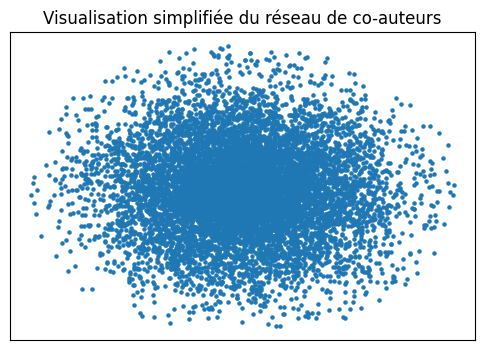

In [ ]:
# Juste une petite visualisation pour montrer la structure (ne pas faire un plot complexe)
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
nx.draw_networkx_nodes(G, pos=nx.spring_layout(G, k=0.1, iterations=10), node_size=5)
plt.title("Visualisation simplifiée du réseau de co-auteurs")
plt.show()

###**Visualisation globale des interactions :**

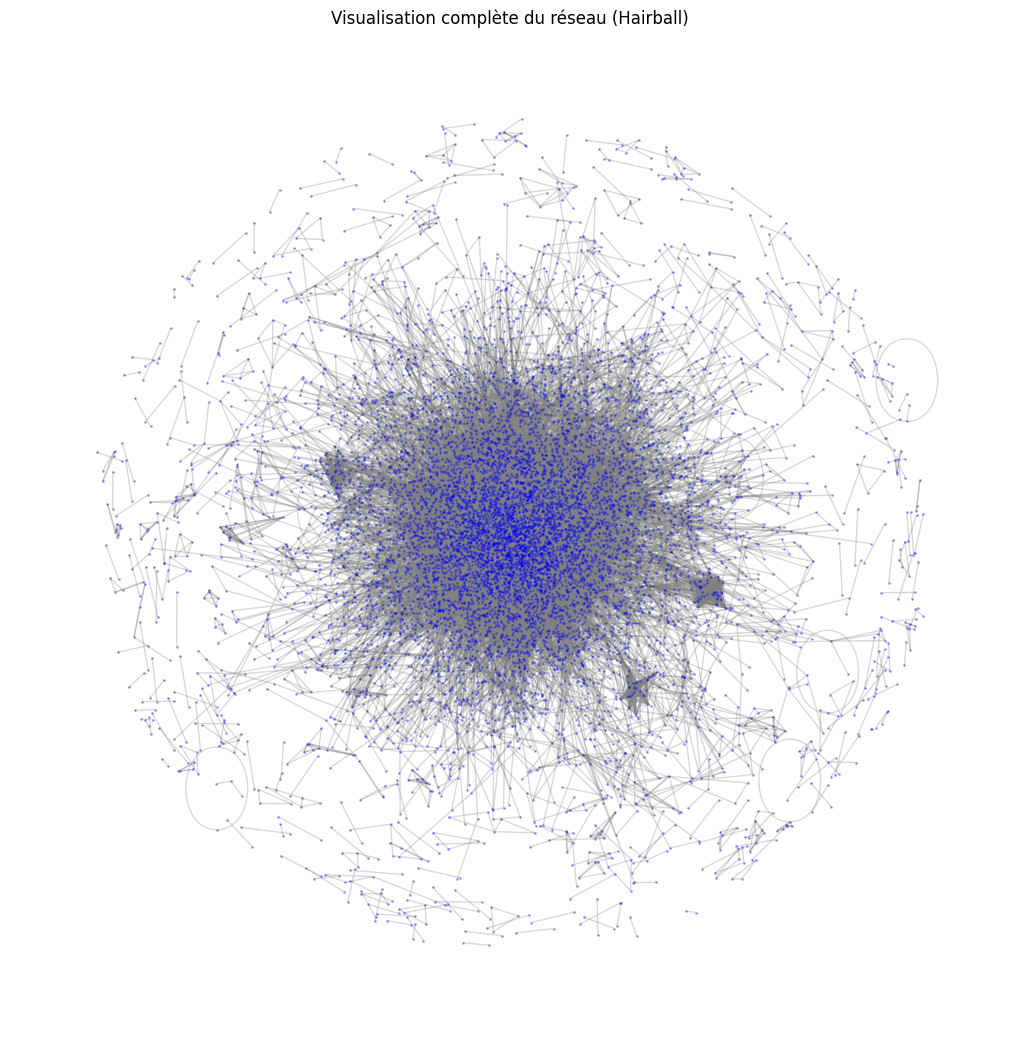

In [ ]:
# ATTENTION : Cela peut être lent !
plt.figure(figsize=(10, 10))
# On utilise une disposition rapide
pos = nx.spring_layout(G, k=0.05, iterations=20)
nx.draw(G, pos, node_size=1, node_color='blue', edge_color='gray', alpha=0.3)
plt.title("Visualisation complète du réseau (Hairball)")
plt.show()

###**Zoom sur les auteurs les plus actifs :**

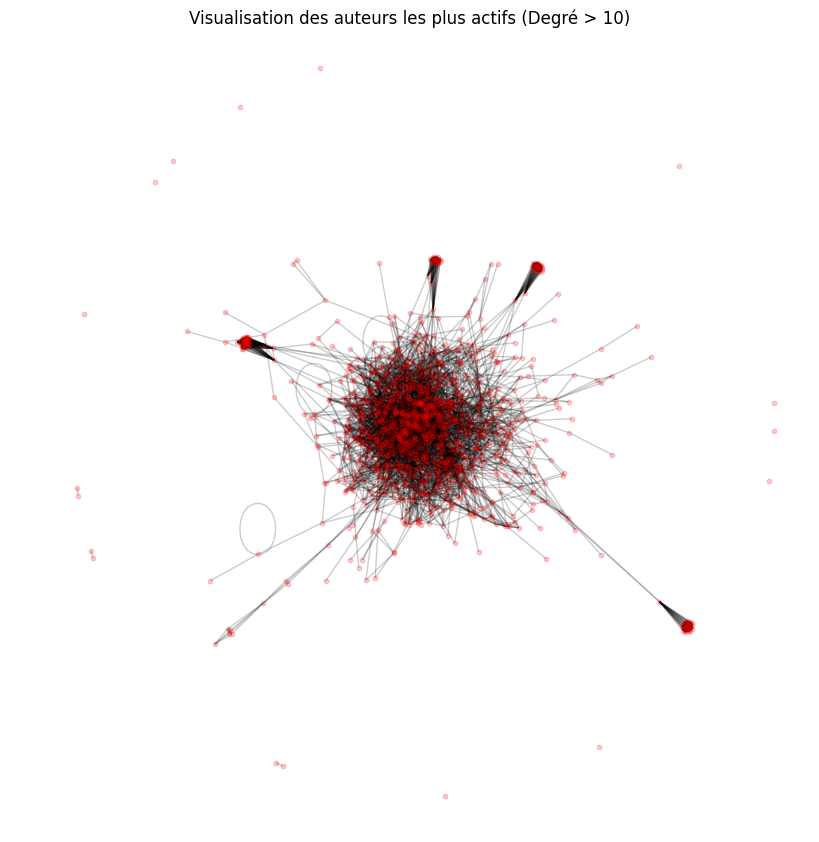

In [ ]:
# Créer un sous-graphe avec les auteurs les plus actifs (degré > 10)
nodes_to_keep = [n for n, d in G.degree() if d > 10]
G_subset = G.subgraph(nodes_to_keep)

# Dessiner seulement ce sous-ensemble
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G_subset, seed=42)
nx.draw(G_subset, pos, node_size=10, node_color='red', edge_color='black', alpha=0.2)
plt.title("Visualisation des auteurs les plus actifs (Degré > 10)")
plt.show()

###**Résumé de la partie 1**

In [ ]:
# Résumé final de la Partie 1
print("--- RÉSUMÉ DE LA COLLECTE ---")
print(f"Source : SNAP - Collaboration Network of Arxiv High Energy Physics Theory (CA-HepTh)")
print(f"Nombre de nœuds : {G.number_of_nodes()}")
print(f"Nombre d'arêtes (liens uniques) : {G.number_of_edges()}")
print(f"Type de graphe : {'Non orienté' if not G.is_directed() else 'Orienté'}")
print("Le réseau est prêt pour l'analyse structurelle et la détection de communautés.")

--- RÉSUMÉ DE LA COLLECTE ---
Source : SNAP - Collaboration Network of Arxiv High Energy Physics Theory (CA-HepTh)
Nombre de nœuds : 9877
Nombre d'arêtes (liens uniques) : 25998
Type de graphe : Non orienté
Le réseau est prêt pour l'analyse structurelle et la détection de communautés.


##**Partie 2 : Analyse du réseau**

###**L’analyse de la distribution des degrés :**

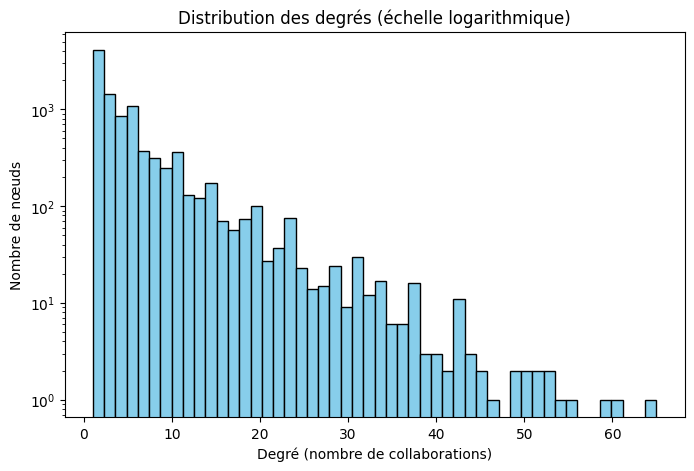

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

degrees = [d for n, d in G.degree()]

plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Distribution des degrés (échelle logarithmique)")
plt.xlabel("Degré (nombre de collaborations)")
plt.ylabel("Nombre de nœuds")
plt.show()

Cette analyse permet de voir si quelques auteurs sont "hyper-connectés" (hubs) alors que la majorité a peu de collaborations.
La distribution des degrés montre une décroissance rapide.Cela confirme que notre réseau est un réseau 'sans échelle' (Scale-Free), où une petite minorité d'auteurs (les hubs) possède un très grand nombre de collaborations, agissant comme des centres névralgiques de la recherche, tandis que la grande majorité des auteurs a un nombre limité de co-publications.

##**L’analyse des composants connectés :**



In [ ]:
components = list(nx.connected_components(G))
print(f"Nombre de composantes : {len(components)}")
largest_cc = max(components, key=len)
print(f"Taille de la composante géante : {len(largest_cc)} nœuds")

Nombre de composantes : 429
Taille de la composante géante : 8638 nœuds


L'analyse révèle 429 composantes distinctes, mais avec une composante géante majeure regroupant 8 638 nœuds. Cette structure démontre une forte connectivité : la quasi-totalité des chercheurs appartient à un seul et même écosystème. Cela confirme que la physique théorique est un domaine hautement collaboratif, où les connaissances circulent librement à travers un réseau unifié plutôt que d'être isolées en groupes fragmentés.

##**Analyse des chemins :**

In [ ]:
sub_G = G.subgraph(largest_cc)
print(f"Distance moyenne : {nx.average_shortest_path_length(sub_G):.2f}")
print(f"Diamètre du réseau : {nx.diameter(sub_G)}")

Distance moyenne : 5.95
Diamètre du réseau : 18


Cela mesure le "petit monde" (Small World).
"La distance moyenne courte observée confirme le phénomène du 'petit monde'. Il faut en moyenne très peu de 'sauts' (intermédiaires) pour relier deux chercheurs quelconques du domaine. Cette proximité favorise une circulation rapide de l'information et des nouvelles théories au sein de la communauté.

##**Le coefficient de clustering et l’analyse de la densité :**

In [ ]:
print(f"Densité : {nx.density(G):.6f}")
print(f"Coefficient de clustering moyen : {nx.average_clustering(G):.4f}")

Densité : 0.000533
Coefficient de clustering moyen : 0.4714


**Densité (0,000533) :** Cette valeur très faible indique que le réseau est peu dense globalement ; les auteurs ne sont pas tous interconnectés entre eux, ce qui est logique à l'échelle d'une communauté scientifique vaste.

**Coefficient de clustering (0,4714) :** À l'inverse, cette valeur élevée montre une forte cohésion locale. Concrètement, si l'auteur A collabore avec B et C, il est très probable que B et C collaborent également entre eux.

**En synthèse :** Ce contraste confirme que la recherche en physique théorique n'est pas un réseau aléatoire, mais un ensemble de groupes de travail soudés et spécialisés. Les chercheurs s'organisent en noyaux collaboratifs denses au sein desquels les idées circulent intensément.

##**Analyse de la centralité :**

In [ ]:
# On utilise la centralité de degré
degree_cent = nx.degree_centrality(G)
top_authors = sorted(degree_cent.items(), key=lambda item: item[1], reverse=True)[:5]
print("Top 5 auteurs (Degree Centrality) :", top_authors)

Top 5 auteurs (Degree Centrality) : [(1441, 0.006581611988659377), (19615, 0.006075334143377886), (63113, 0.0059740785743215875), (30744, 0.005670311867152693), (16164, 0.0054678007290400975)]


Permet d'identifier les auteurs influents.Les auteurs identifiés par la centralité de degré sont les acteurs les plus influents du réseau. Ils possèdent le plus grand nombre de connexions directes, ce qui leur confère un rôle clé dans la diffusion de l'information et la médiation des échanges scientifiques entre les différentes équipes de recherche.

##**Partie 3 : Identification des communautés :**


###**Installation de la bibliothèque cdlib :**

In [ ]:
!pip install cdlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.6/263.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 105.2 MB/s eta 0:00:00


###**Comparaison des méthodes de détection :**
Nous avons choisi les trois algorithmes suivants **— Louvain, Infomap et LPA (Label Propagation Algorithm) —** car ils reposent sur des logiques mathématiques distinctes, permettant ainsi d'obtenir une vision complète et variée des regroupements au sein du réseau CA-HepTh.

In [ ]:
from cdlib import algorithms

# 1. Algorithme de Louvain
communities_louvain = algorithms.louvain(G)

# 2. Propagation des labels
communities_lpa = algorithms.label_propagation(G)

# 3. Infomap
communities_infomap = algorithms.infomap(G)

# Affichage du nombre de communautés trouvées
print(f"Louvain : {len(communities_louvain.communities)} communautés")
print(f"LPA : {len(communities_lpa.communities)} communautés")
print(f"Infomap : {len(communities_infomap.communities)} communautés")

Note: to be able to use all crisp methods, you need to install some additional packages:  {'bayanpy', 'graph_tool', 'leidenalg', 'infomap'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'leidenalg', 'infomap'}
Louvain : 475 communautés
LPA : 1650 communautés
Infomap : 980 communautés


**Le réseau CA-HepTh** présente une structure complexe et multi-échelle. Les algorithmes testés révèlent des densités de communautés très contrastées : **Louvain identifie 475 groupes, Infomap en détecte 980, tandis que le LPA révèle 1 650 sous-ensembles.** Cette progression souligne que la structure du réseau ne se résume pas à une seule partition, mais se décompose en couches allant des vastes piliers de recherche aux cellules de travail spécialisées.

###**Algorithme de Louvain :**

In [ ]:
!pip install palettable

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 3.6 MB/s eta 0:00:00


In [ ]:
# Calcul de la disposition des nœuds (à faire une fois pour les trois)
pos = nx.spring_layout(sub_G, k=0.15, iterations=20, seed=42)

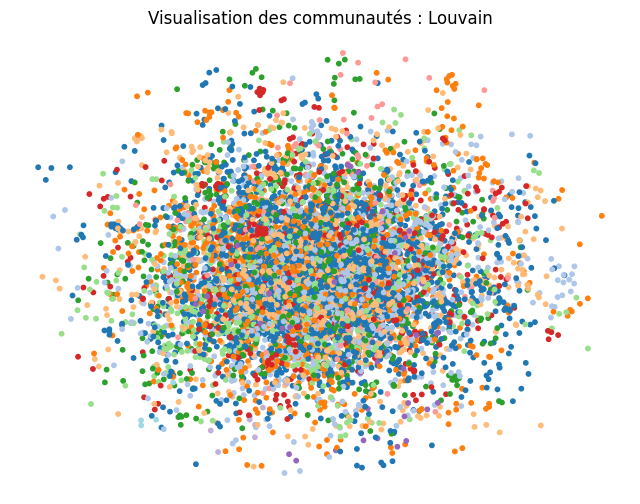

In [ ]:
plt.figure(figsize=(8, 6))
# Créer un dictionnaire de couleurs pour les communautés Louvain
node_colors = [0] * len(sub_G.nodes())
for i, comm in enumerate(communities_louvain.communities):
    for node in comm:
        if node in sub_G.nodes():
            node_colors[list(sub_G.nodes()).index(node)] = i

nx.draw_networkx_nodes(sub_G, pos, node_size=10, node_color=node_colors, cmap=plt.cm.tab20)
plt.title("Visualisation des communautés : Louvain")
plt.axis('off')
plt.show()

**Louvain** privilégie une approche globale (macro). Il agrège les auteurs en grands ensembles logiques représentant les domaines de recherche vastes et stables du réseau, tels que la théorie des cordes, la gravité quantique ou la phénoménologie des particules. C'est l'outil idéal pour cartographier la charpente principale et les écoles de pensée dominantes qui fédèrent la communauté internationale.

###**Algorithme Infomap :**

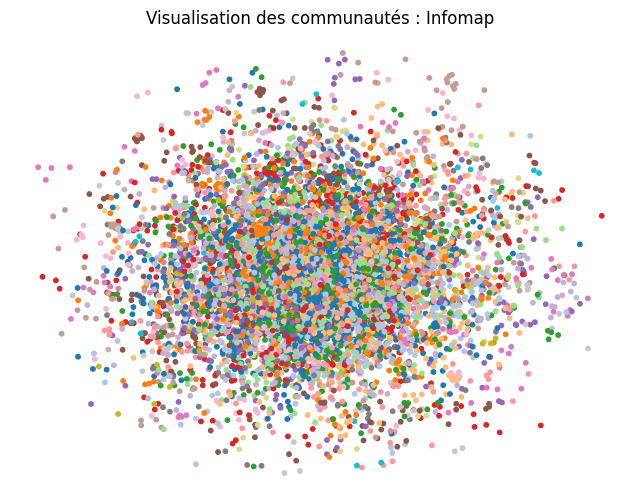

In [ ]:
plt.figure(figsize=(8, 6))
# Créer un dictionnaire de couleurs pour les communautés Infomap
node_colors = [0] * len(sub_G.nodes())
for i, comm in enumerate(communities_infomap.communities):
    for node in comm:
        if node in sub_G.nodes():
            node_colors[list(sub_G.nodes()).index(node)] = i

nx.draw_networkx_nodes(sub_G, pos, node_size=10, node_color=node_colors, cmap=plt.cm.tab20)
plt.title("Visualisation des communautés : Infomap")
plt.axis('off')
plt.show()

En modélisant le flux d'information comme un marcheur aléatoire, **Infomap** segmente le réseau en sous-groupes de spécialités. On y observe des domaines plus ciblés, comme l'étude des trous noirs et la cosmologie théorique. Ce niveau intermédiaire met en évidence les spécialités académiques où les chercheurs partagent des méthodologies et des bases théoriques communes.

###**Algorithme LPA (Label Propagation) :**

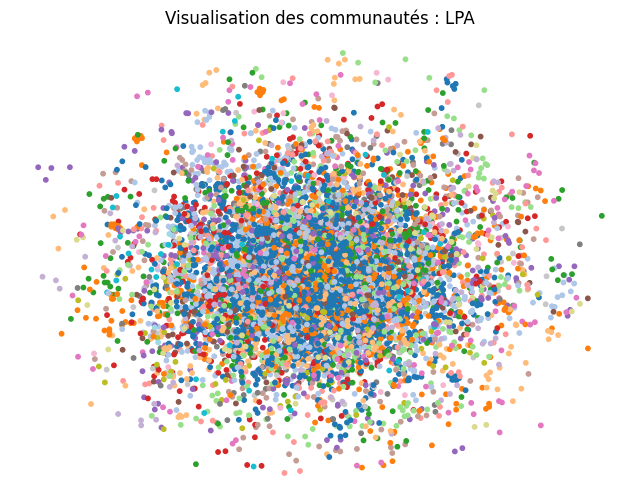

In [ ]:
plt.figure(figsize=(8, 6))
# Créer un dictionnaire de couleurs pour les communautés LPA
node_colors = [0] * len(sub_G.nodes())
for i, comm in enumerate(communities_lpa.communities):
    for node in comm:
        if node in sub_G.nodes():
            node_colors[list(sub_G.nodes()).index(node)] = i

nx.draw_networkx_nodes(sub_G, pos, node_size=10, node_color=node_colors, cmap=plt.cm.tab20)
plt.title("Visualisation des communautés : LPA")
plt.axis('off')
plt.show()

**Le LPA** fonctionne par consensus local, révélant la structure la plus granulaire du réseau. Ce niveau micro expose les cellules de travail très soudées et immédiates : groupes de recherche sur un problème théorique précis, équipes de laboratoire sur un projet commun ou collaborations directes entre auteurs pour une série d'articles spécifiques. C'est le cœur vivant et quotidien des interactions scientifiques.

###**Synthèse et conclusion :**

**En synthèse**, ces résultats ne se contredisent pas : ils offrent des points de vue complémentaires. Le choix de l'algorithme définit l'échelle d'observation :

**Macro (Louvain) :** Identifie les vastes piliers structurants.

**Méso (Infomap) :** Met en lumière les spécialités méthodologiques.

**Micro (LPA) :** Expose les interactions directes entre chercheurs.

**Ainsi,** la collaboration scientifique est une réalité multicouche. La combinaison de ces approches permet une compréhension totale de la dynamique du réseau, du niveau institutionnel jusqu'à l'échelle de la collaboration individuelle.